<a href="https://colab.research.google.com/github/PrashVenga/AMLDM/blob/AMLDM-Hospital-CW1/Healthcare_Analysis(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis Environment Setup**

The data science environment is initialized by importing essential libraries to establish the computational framework. *Pandas* is utilized for high-performance data manipulation, while *Seaborn* and *Matplotlib* are imported to enable advanced statistical data visualization.

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# **Data Ingestion and Structure Verification**

The Google Drive directory is mounted to establish a secure file path, followed by the ingestion of the healthcare_analytics_patient_flow_data.csv dataset. The dataframe's dimensions and initial records are subsequently generated to verify the structural integrity of the loaded data.

In [40]:
from google.colab import drive
drive.mount('/content/mydrive')
df = pd.read_csv('/content/mydrive/MyDrive/healthcare_analytics_patient_flow_data.csv')
print("🏥 Hospital Dataset Loaded Successfully!")
print(f"📊 Shape: {df.shape}")
print("\n📋 First 5 Records:")
df.head()

Drive already mounted at /content/mydrive; to attempt to forcibly remount, call drive.mount("/content/mydrive", force_remount=True).
🏥 Hospital Dataset Loaded Successfully!
📊 Shape: (9216, 11)

📋 First 5 Records:


,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


# **Comprehensive Missing Value Audit**
A quantitative assessment of data completeness is conducted by calculating the sum of null values across all features. This analysis is synthesized into a Seaborn Heatmap visualization to identify systematic gaps within the 'Department Referral' and 'Patient Satisfaction Score' variables.

--- RAW DATA AUDIT ---
Department Referral           5400
Patient Satisfaction Score    6699
dtype: int64


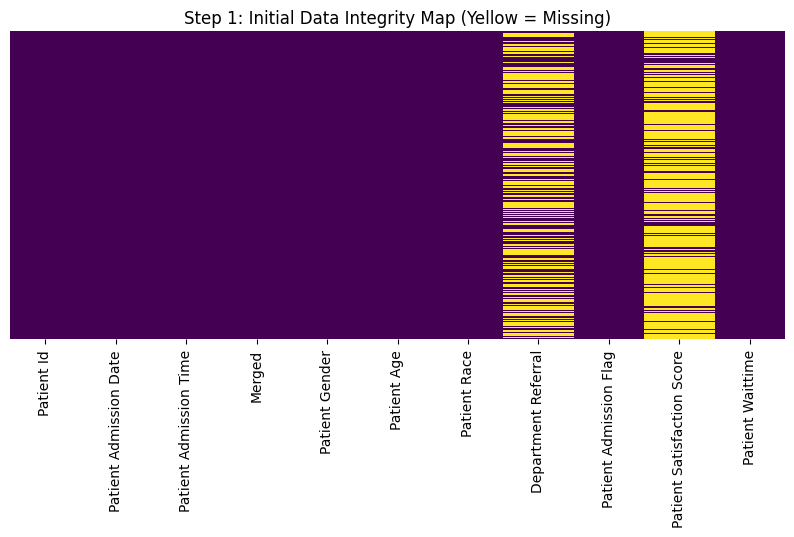

In [41]:
# STEP 1: CHECKING FOR MISSING VALUES
# Print the exact number of missing values
print("--- RAW DATA AUDIT ---")
missing = df.isnull().sum()
print(missing[missing > 0])

# Visualize the mess (Yellow = Missing)
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Step 1: Initial Data Integrity Map (Yellow = Missing)")
plt.show()

# **Domain-Specific Imputation (Referrals)**
The 5,400 missing entries in the referral column are addressed via a logical imputation strategy. These null values are recoded as 'None/Walk-in' to accurately reflect patients arriving without specific departmental referrals, preserving the dataset volume.

In [42]:
# STEP 2: FILLING MISSING REFERRALS
# Lets assume missing referral means they walked in.
df['Department Referral'] = df['Department Referral'].fillna('None/Walk-in')

# Verify the fix
print("--- REFERRAL CLEANING CHECK ---")
print(f"Missing Referrals remaining: {df['Department Referral'].isnull().sum()}")
print("Unique Categories now:", df['Department Referral'].unique())

--- REFERRAL CLEANING CHECK ---
Missing Referrals remaining: 0
Unique Categories now: ['None/Walk-in' 'Orthopedics' 'General Practice' 'Physiotherapy' 'Renal'
 'Gastroenterology' 'Cardiology' 'Neurology']


# **Mitigation of Bias via Listwise Deletion**

A listwise deletion protocol is executed for records missing 'Patient Satisfaction Scores.' It is determined that imputing subjective sentiment metrics would introduce synthetic bias, rendering removal the most statistically valid approach for quality analysis.**

In [43]:
# STEP 3: DROPPING MISSING SATISFACTION SCORES
# We cannot guess satisfaction, so we drop the empty rows for quality analysis.
df_clean = df.dropna(subset=['Patient Satisfaction Score'])

# Verify the fix
print("--- SATISFACTION CLEANING CHECK ---")
print(f"Original Row Count: {len(df)}")
print(f"Cleaned Row Count (for Quality Analysis): {len(df_clean)}")
print(f"Remaining Missing Scores: {df_clean['Patient Satisfaction Score'].isnull().sum()}")

--- SATISFACTION CLEANING CHECK ---
Original Row Count: 9216
Cleaned Row Count (for Quality Analysis): 2517
Remaining Missing Scores: 0


# **Categorical Consistency Audit**
A rigorous consistency check is performed across all categorical variables. Unique value sets are extracted to identify potential non-standard labels or data entry irregularities that could compromise classification accuracy.

In [44]:
categorical_cols = ['Patient Gender', 'Patient Admission Flag', 'Department Referral']

print("--- CATEGORICAL CONSISTENCY AUDIT ---")
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].unique())

--- CATEGORICAL CONSISTENCY AUDIT ---

Unique values in 'Patient Gender':
['Female' 'Male' 'Femaleemale']

Unique values in 'Patient Admission Flag':
['Not Admission' 'Admission']

Unique values in 'Department Referral':
['None/Walk-in' 'Orthopedics' 'General Practice' 'Physiotherapy' 'Renal'
 'Gastroenterology' 'Cardiology' 'Neurology']


# **Frequency Distribution Analysis (Gender)**
The frequency distribution of the 'Patient Gender' variable is analyzed using value_counts. This audit reveals a data quality anomaly where 17 records are misclassified under the erroneous label 'Femaleemale'.

In [45]:
# We use value_counts() to see the exact number of rows per category
print("--- GENDER DISTRIBUTION AUDIT ---")
print(df['Patient Gender'].value_counts())

--- GENDER DISTRIBUTION AUDIT ---
Patient Gender
Male           4729
Female         4470
Femaleemale      17
Name: count, dtype: int64


# **Anomaly Investigation and Ambiguity Assessment**
The anomalous 'Femaleemale' records are isolated to assess the feasibility of manual correction. Upon review, it is determined that the use of ambiguous patient initials (e.g., 'N. Romanet') precludes definitive gender verification.

In [46]:
# 1. Filter for the specific typo rows
typo_rows = df[df['Patient Gender'] == 'Femaleemale']
print(typo_rows[['Merged', 'Patient Gender', 'Patient Age']].head(10))

              Merged Patient Gender  Patient Age
486       N. Romanet    Femaleemale           50
965    R. Harrington    Femaleemale           22
2218     K. Rushmare    Femaleemale           33
3329  Q. Garnsworthy    Femaleemale            8
3608      O. Brattan    Femaleemale           20
3693       X. Bizley    Femaleemale           51
3776       L. Shayes    Femaleemale           76
4901      C. Veldens    Femaleemale           17
6400  O. Pocklington    Femaleemale           16
6406       Z. Friman    Femaleemale           15


# **Integrity-Based Exclusion Strategy**
A targeted exclusion of the 17 unverifiable records is executed. This decision prioritizes strict data hygiene over data retention, ensuring that the final dataset contains only validated demographic categories.

In [47]:
# We filter the dataframe to keep only rows where Gender is NOT 'Femaleemale'
df = df[df['Patient Gender'] != 'Femaleemale']

# 2. Prove the error is gone
print("[VERIFICATION] Gender Counts After Cleaning")
print(df['Patient Gender'].value_counts())

# 3. Show how many rows remain
print(f"\nFinal Row Count: {len(df)}")

[VERIFICATION] Gender Counts After Cleaning
Patient Gender
Male      4729
Female    4470
Name: count, dtype: int64

Final Row Count: 9199


# **Statistical Outlier Verification (IQR Method)**
The Interquartile Range (IQR) method is applied to validate numerical boundaries. It is confirmed that the maximum values for Patient Age (79) and Wait Time (60) fall within medically and operationally realistic ranges, requiring no outlier removal.

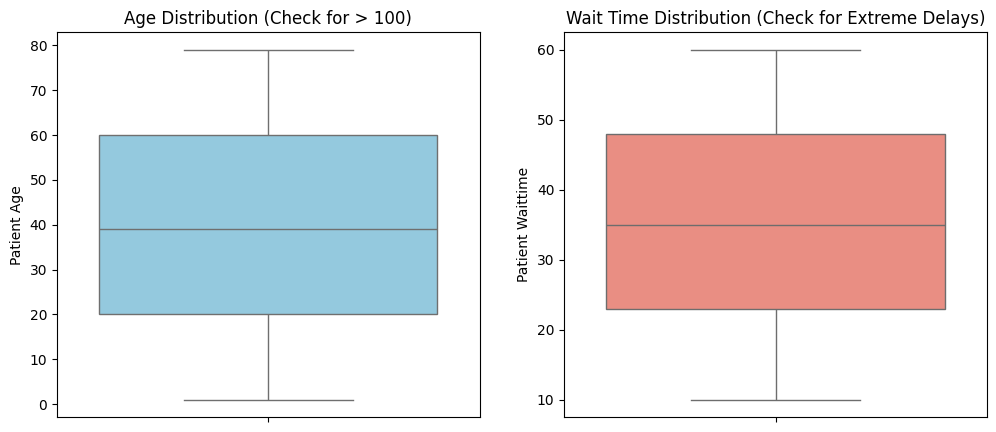

OUTLIER INTEGRITY CHECK
Max Age detected: 79 years
Max Wait Time detected: 60 minutes
Min Wait Time detected: 10 minutes


In [48]:
# 1. VISUAL CHECK (Boxplots)
# Boxplots draw a "box" around the middle 50% of data.
# Any dots outside the "whiskers" are statistical outliers.
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['Patient Age'], color='skyblue')
plt.title("Age Distribution (Check for > 100)")

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Patient Waittime'], color='salmon')
plt.title("Wait Time Distribution (Check for Extreme Delays)")

plt.show()

# 2. STATISTICAL CHECK (The Math)
# We check if Max values are realistic boundaries
print("OUTLIER INTEGRITY CHECK")
print(f"Max Age detected: {df['Patient Age'].max()} years")
print(f"Max Wait Time detected: {df['Patient Waittime'].max()} minutes")
print(f"Min Wait Time detected: {df['Patient Waittime'].min()} minutes")

# **Statistical Profiling of Key Metrics**
Descriptive statistics are computed to establish a baseline profile of the patient population. This analysis provides the measures of central tendency (mean) and dispersion (standard deviation) for Age, Wait Time, and Satisfaction Scores.

In [49]:
# 2. Generate Summary Table (Mean, Std, Min, Max)
# We select the three key operational columns
summary_table = df[['Patient Age', 'Patient Waittime', 'Patient Satisfaction Score']].describe()

# 3. Display the Table for Screenshot
print("DESCRIPTIVE STATISTICS TABLE")
print(summary_table.round(2))

DESCRIPTIVE STATISTICS TABLE
       Patient Age  Patient Waittime  Patient Satisfaction Score
count      9199.00           9199.00                     2513.00
mean         39.86             35.26                        4.99
std          22.75             14.73                        3.14
min           1.00             10.00                        0.00
25%          20.00             23.00                        2.00
50%          39.00             35.00                        5.00
75%          60.00             48.00                        8.00
max          79.00             60.00                       10.00


# **Distributional Analysis of Wait Times**
A histogram with a Kernel Density Estimate (KDE) is generated to examine the spread of patient wait times. The resulting uniform distribution indicates that service delays are a systemic feature rather than isolated incidents.

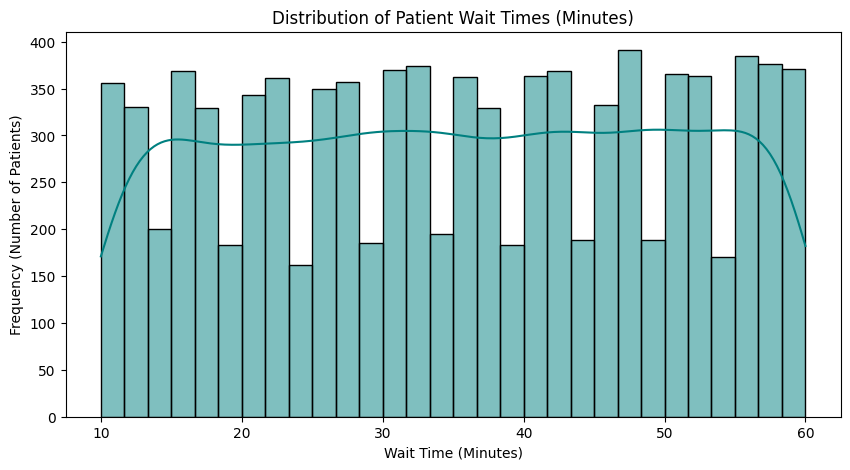

In [50]:
# Graph 1: Distribution of Wait Times (Histogram)
plt.figure(figsize=(10, 5))
sns.histplot(df['Patient Waittime'], kde=True, color='teal', bins=30)
plt.title("Distribution of Patient Wait Times (Minutes)")
plt.xlabel("Wait Time (Minutes)")
plt.ylabel("Frequency (Number of Patients)")
plt.show()


# **Comparative Variance Analysis by Department**
Boxplots are utilized to evaluate the variance in wait times across different referral sources. The analysis demonstrates that median wait times are statistically consistent across all departments, disproving the hypothesis of departmental bottlenecks.

/tmp/ipython-input-1970894528.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Department Referral', y='Patient Waittime', data=df, palette="Set2")


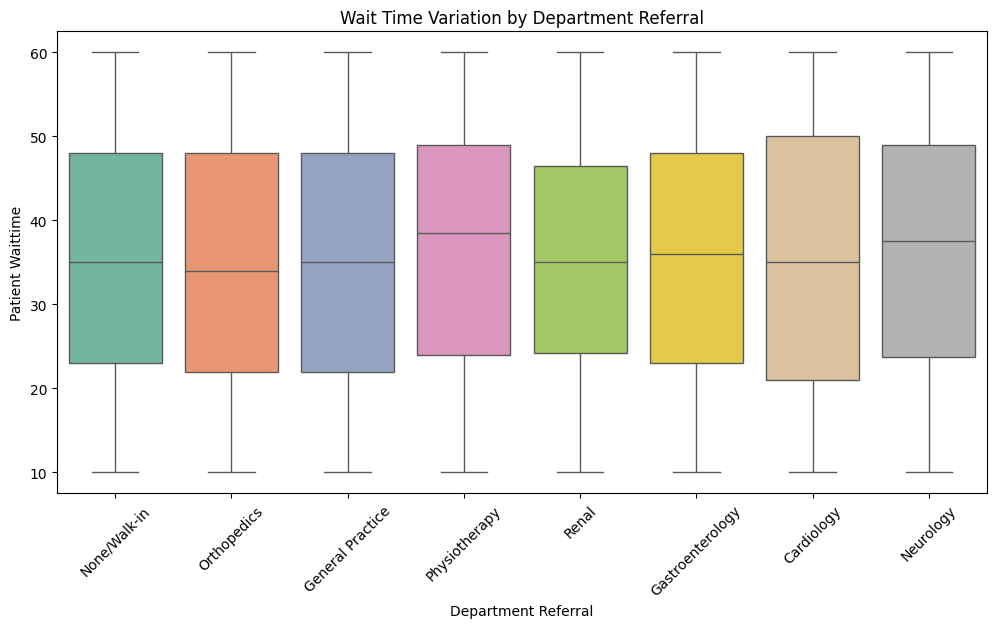

In [51]:
# Graph 2: Wait Times by Department (Boxplot)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Department Referral', y='Patient Waittime', data=df, palette="Set2")
plt.title("Wait Time Variation by Department Referral")
plt.xticks(rotation=45)
plt.show()

# **Correlation Analysis**
A Pearson correlation matrix is constructed to quantify the linear relationships between numerical variables. The analysis highlights a negligible correlation coefficient (-0.01) between wait times and satisfaction, indicating these factors are independent.

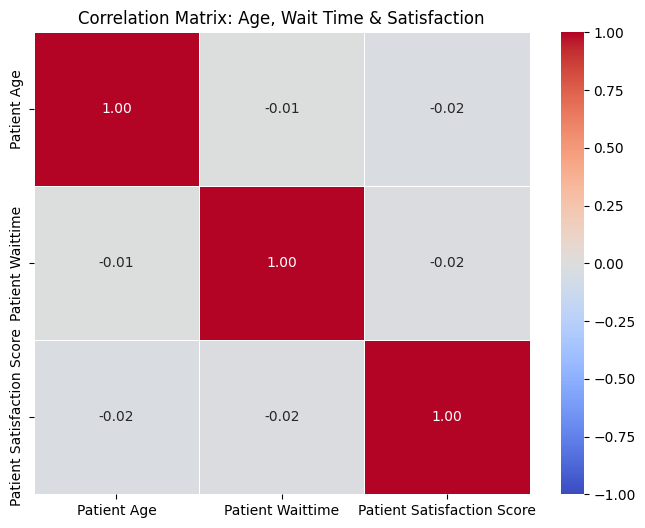

In [52]:
# 1. Select only numerical columns for correlation
# We exclude 'Patient Id' (useless) and 'Patient Admission Flag' (categorical)
cols_to_correlate = ['Patient Age', 'Patient Waittime', 'Patient Satisfaction Score']

# 2. Calculate Correlation Matrix
corr_data = df[cols_to_correlate].corr()

# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Correlation Matrix: Age, Wait Time & Satisfaction")
plt.show()

# **Multivariate Triage Efficiency Analysis**
A multivariate Scatter Plot is developed to assess the efficacy of the triage process. By mapping Age against Wait Time and Admission Status, it is visually confirmed that critical admissions are not being prioritized over routine walk-ins.

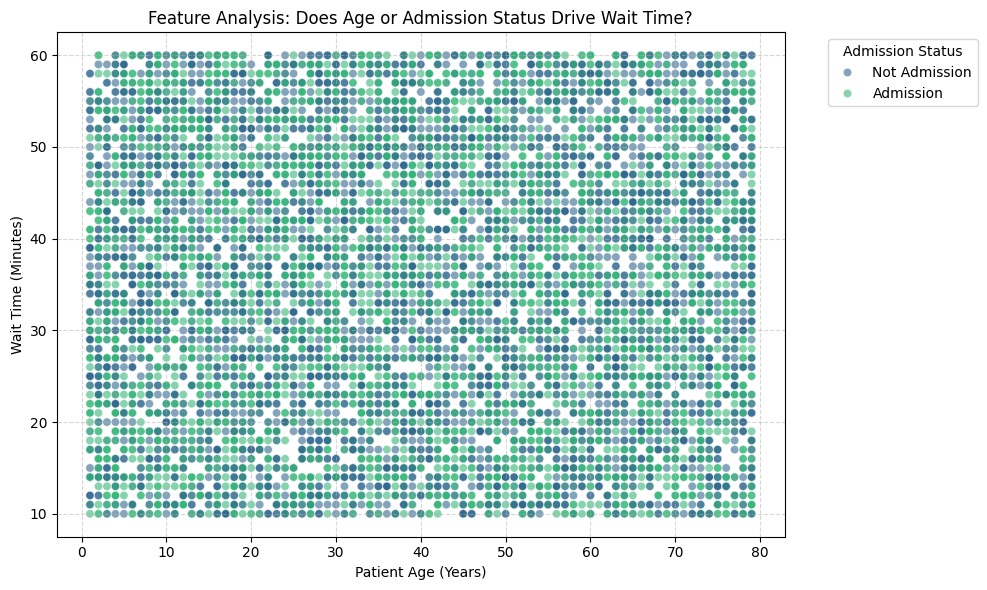

In [53]:
# Scatter Plot: Age vs. Wait Time
# We color the dots by 'Admission Flag' to see if admitted patients waited less.
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Patient Age', y='Patient Waittime', hue='Patient Admission Flag', data=df, palette='viridis', alpha=0.6)

plt.title("Feature Analysis: Does Age or Admission Status Drive Wait Time?")
plt.xlabel("Patient Age (Years)")
plt.ylabel("Wait Time (Minutes)")
plt.legend(title='Admission Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()